# Tarea 1 - Clasificación de Imágenes con Imagenette

**Dataset:** Imagenette (10 clases de ImageNet)

**Objetivo:** Implementar y entrenar un modelo de clasificación de imágenes desde cero, aplicando técnicas de regularización y evaluando el desempeño con métricas estándar.

**Weights & Biases Project:** https://wandb.ai/eo214205-ort/Tarea1

Este proyecto contiene el registro completo de todos los experimentos realizados, incluyendo métricas, gráficas de entrenamiento y comparaciones entre diferentes configuraciones.

## 1. Setup e Importaciones

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import Imagenette
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from torchinfo import summary
import wandb
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\Enrique\anaconda3\envs\taller-dl\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\Enrique\anaconda3\envs\taller-dl\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an 

Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070


### Configuración de Weights & Biases

In [2]:
wandb.login()

wandb: Currently logged in as: eo214205 (eo214205-ort) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Exploración y Análisis de Datos

In [3]:
data_root = './data'

temp_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_temp = Imagenette(
    root=data_root,
    split='train',
    size='160px',
    download=False,
    transform=temp_transform
)

val_dataset_temp = Imagenette(
    root=data_root,
    split='val',
    size='160px',
    download=False,
    transform=temp_transform
)

print(f'Número de imágenes de entrenamiento: {len(train_dataset_temp)}')
print(f'Número de imágenes de validación: {len(val_dataset_temp)}')
print(f'Número de clases: {len(train_dataset_temp.classes)}')
print(f'Clases: {train_dataset_temp.classes}')

Número de imágenes de entrenamiento: 9469
Número de imágenes de validación: 3925
Número de clases: 10
Clases: [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]


### Análisis de Balance de Clases


=== Distribución de Clases en Entrenamiento ===
tench               :  963 imágenes (10.2%)
English springer    :  955 imágenes (10.1%)
cassette player     :  993 imágenes (10.5%)
chain saw           :  858 imágenes (9.1%)
church              :  941 imágenes (9.9%)
French horn         :  956 imágenes (10.1%)
garbage truck       :  961 imágenes (10.1%)
gas pump            :  931 imágenes (9.8%)
golf ball           :  951 imágenes (10.0%)
parachute           :  960 imágenes (10.1%)

=== Distribución de Clases en Validación ===
tench               :  387 imágenes (9.9%)
English springer    :  395 imágenes (10.1%)
cassette player     :  357 imágenes (9.1%)
chain saw           :  386 imágenes (9.8%)
church              :  409 imágenes (10.4%)
French horn         :  394 imágenes (10.0%)
garbage truck       :  389 imágenes (9.9%)
gas pump            :  419 imágenes (10.7%)
golf ball           :  399 imágenes (10.2%)
parachute           :  390 imágenes (9.9%)


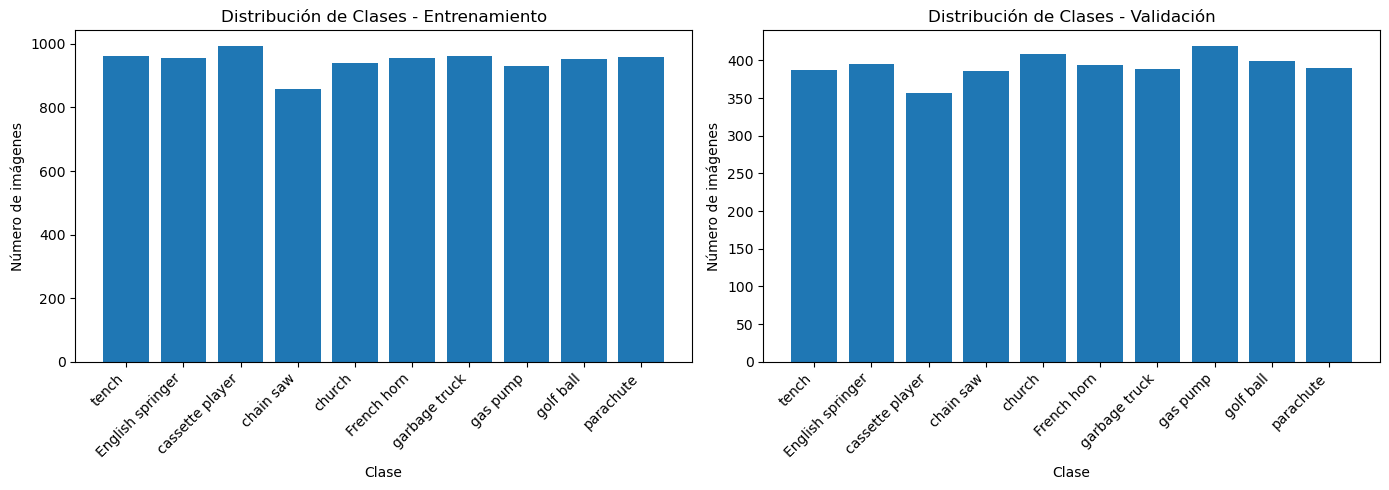

In [4]:
train_labels = [label for _, label in train_dataset_temp]
val_labels = [label for _, label in val_dataset_temp]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print('\n=== Distribución de Clases en Entrenamiento ===')
for class_idx in sorted(train_counts.keys()):
    class_name = str(train_dataset_temp.classes[class_idx][0]) if isinstance(train_dataset_temp.classes[class_idx], tuple) else str(train_dataset_temp.classes[class_idx])
    count = train_counts[class_idx]
    percentage = (count / len(train_labels)) * 100
    print(f'{class_name:20s}: {count:4d} imágenes ({percentage:.1f}%)')

print('\n=== Distribución de Clases en Validación ===')
for class_idx in sorted(val_counts.keys()):
    class_name = str(val_dataset_temp.classes[class_idx][0]) if isinstance(val_dataset_temp.classes[class_idx], tuple) else str(val_dataset_temp.classes[class_idx])
    count = val_counts[class_idx]
    percentage = (count / len(val_labels)) * 100
    print(f'{class_name:20s}: {count:4d} imágenes ({percentage:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

class_names = [str(train_dataset_temp.classes[i][0]) if isinstance(train_dataset_temp.classes[i], tuple) else str(train_dataset_temp.classes[i]) for i in sorted(train_counts.keys())]
train_values = [train_counts[i] for i in sorted(train_counts.keys())]
val_values = [val_counts[i] for i in sorted(val_counts.keys())]

ax1.bar(range(len(class_names)), train_values)
ax1.set_xlabel('Clase')
ax1.set_ylabel('Número de imágenes')
ax1.set_title('Distribución de Clases - Entrenamiento')
ax1.set_xticks(range(len(class_names)))
ax1.set_xticklabels(class_names, rotation=45, ha='right')

ax2.bar(range(len(class_names)), val_values)
ax2.set_xlabel('Clase')
ax2.set_ylabel('Número de imágenes')
ax2.set_title('Distribución de Clases - Validación')
ax2.set_xticks(range(len(class_names)))
ax2.set_xticklabels(class_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Análisis de Dimensiones y Valores de Imágenes

In [5]:
sample_images = [train_dataset_temp[i][0] for i in range(min(100, len(train_dataset_temp)))]

print(f'\n=== Análisis de Características de Imágenes ===')
print(f'Forma de imagen (ejemplo): {sample_images[0].shape}')
print(f'Tipo de dato: {sample_images[0].dtype}')

all_means = []
all_stds = []
all_mins = []
all_maxs = []

for img in sample_images:
    all_means.append(img.mean().item())
    all_stds.append(img.std().item())
    all_mins.append(img.min().item())
    all_maxs.append(img.max().item())

print(f'Rango de valores: [{min(all_mins):.3f}, {max(all_maxs):.3f}]')
print(f'\nMedia promedio de imágenes: {sum(all_means)/len(all_means):.3f}')
print(f'Desviación estándar promedio: {sum(all_stds)/len(all_stds):.3f}')


=== Análisis de Características de Imágenes ===
Forma de imagen (ejemplo): torch.Size([3, 160, 213])
Tipo de dato: torch.float32
Rango de valores: [0.000, 1.000]

Media promedio de imágenes: 0.419
Desviación estándar promedio: 0.240


### Visualización de Muestras

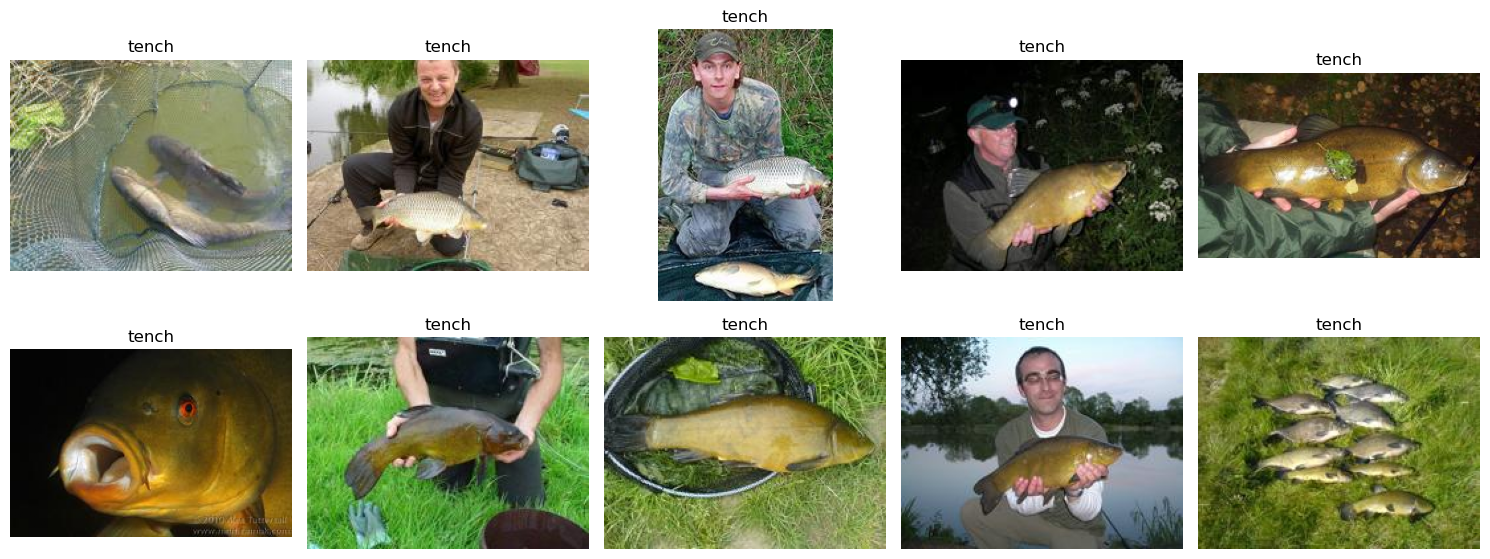

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img, label = train_dataset_temp[i * 100]
    img_display = img.permute(1, 2, 0).numpy()
    axes[i].imshow(img_display)
    class_name = str(train_dataset_temp.classes[label][0]) if isinstance(train_dataset_temp.classes[label], tuple) else str(train_dataset_temp.classes[label])
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Decisiones de Preprocesamiento

**Basado en el análisis anterior:**

1. **Tamaño de imagen:** El dataset '160px' de Imagenette mantiene el aspect ratio original, resultando en imágenes de dimensiones variables. Aplicaremos resize a 160x160 para estandarizar el tamaño y permitir procesamiento por lotes en la red neuronal.

2. **Normalización:** Los valores están en rango [0, 1] después de ToTensor(). Aplicaremos normalización con media y desviación estándar de ImageNet (valores estándar ampliamente utilizados) para centrar los datos en 0 y facilitar el entrenamiento.

3. **Balance de clases:** El dataset muestra distribución relativamente balanceada entre clases (cada clase representa ~10% del total). No se requieren técnicas especiales de balanceo.

4. **Data Augmentation (solo entrenamiento):** Aplicaremos transformaciones moderadas para aumentar la variabilidad sin distorsionar las características principales:
   - Flip horizontal aleatorio (objetos pueden aparecer invertidos)
   - Rotación pequeña (±10 grados para no deformar objetos)
   - No usaremos crop agresivo dado el tamaño reducido de las imágenes

5. **Sin augmentation en validación:** Para evaluar el modelo de forma consistente y medir su capacidad de generalización real.

## 3. Preparación de Datos con Transformaciones

In [7]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform_train_basic = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_train_augmented = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_val = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

### Visualización de Data Augmentation

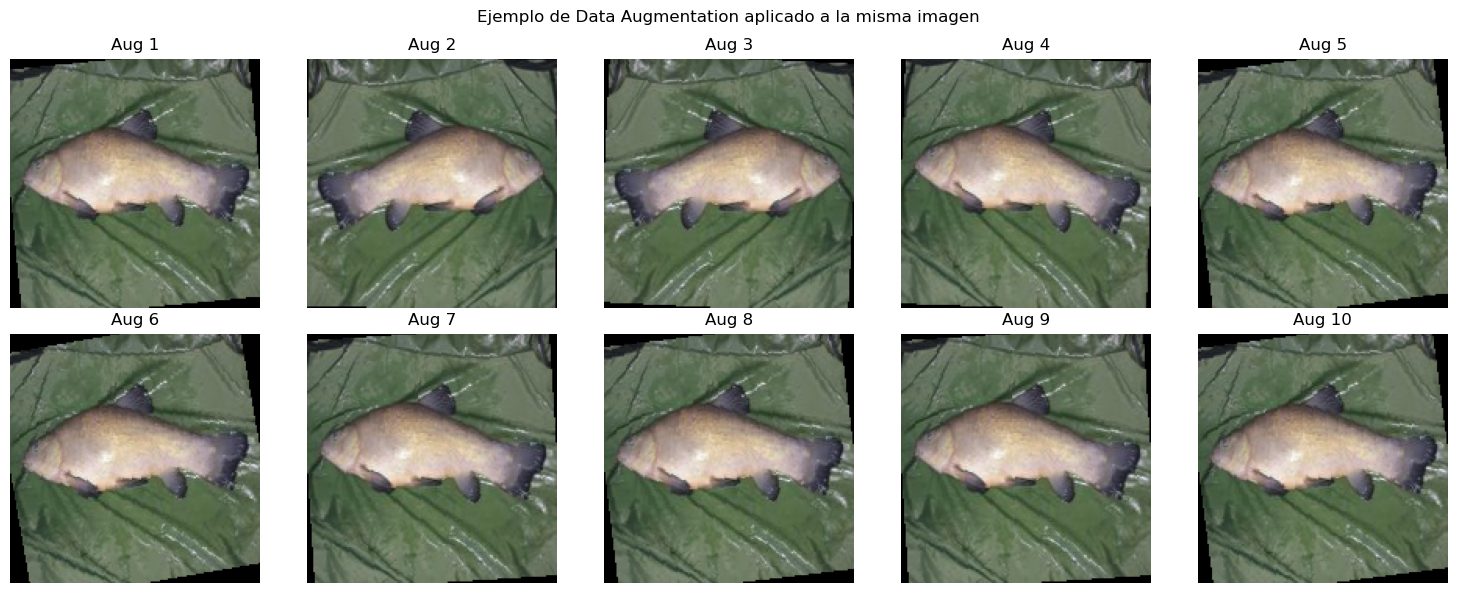

In [8]:
train_dataset_aug = Imagenette(
    root=data_root,
    split='train',
    size='160px',
    download=False,
    transform=transform_train_augmented
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

idx = 42
mean_np = np.array(mean).reshape(3, 1, 1)
std_np = np.array(std).reshape(3, 1, 1)

for i in range(10):
    img, label = train_dataset_aug[idx]
    img_display = img.numpy()
    img_display = img_display * std_np + mean_np
    img_display = np.clip(img_display, 0, 1)
    img_display = img_display.transpose(1, 2, 0)
    axes[i].imshow(img_display)
    axes[i].set_title(f'Aug {i+1}')
    axes[i].axis('off')

plt.suptitle('Ejemplo de Data Augmentation aplicado a la misma imagen')
plt.tight_layout()
plt.show()

## 4. Arquitectura del Modelo

In [9]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 10 * 10, 512)
        self.relu5 = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        x = self.conv4(x)
        x = self.relu4(x)
        x = self.pool4(x)
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu5(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [10]:
model_test = ImprovedCNN(num_classes=10, dropout_rate=0.5)
summary(model_test, input_size=(1, 3, 160, 160))

Layer (type:depth-idx)                   Output Shape              Param #
ImprovedCNN                              [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 160, 160]         1,792
├─ReLU: 1-2                              [1, 64, 160, 160]         --
├─MaxPool2d: 1-3                         [1, 64, 80, 80]           --
├─Conv2d: 1-4                            [1, 128, 80, 80]          73,856
├─ReLU: 1-5                              [1, 128, 80, 80]          --
├─MaxPool2d: 1-6                         [1, 128, 40, 40]          --
├─Conv2d: 1-7                            [1, 256, 40, 40]          295,168
├─ReLU: 1-8                              [1, 256, 40, 40]          --
├─MaxPool2d: 1-9                         [1, 256, 20, 20]          --
├─Conv2d: 1-10                           [1, 512, 20, 20]          1,180,160
├─ReLU: 1-11                             [1, 512, 20, 20]          --
├─MaxPool2d: 1-12                        [1, 512, 10, 10]         

## 5. Funciones de Entrenamiento y Evaluación

In [11]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            outputs = model(x)
            loss = criterion(outputs, y)
            
            running_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, experiment_name, patience=None):
    wandb.init(project='Tarea1', name=experiment_name, reinit=True)
    wandb.watch(model, log='all')
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if scheduler is not None:
            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]['lr']
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc,
                'learning_rate': current_lr
            })
        else:
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc
            })
        
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} '
              f'Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')
        
        if patience is not None:
            if val_loss < best_val_loss - 0.001:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping en epoch {epoch+1}')
                break
    
    wandb.finish()
    
    return train_losses, train_accs, val_losses, val_accs

## 6. Entrenamiento del Modelo

In [12]:
batch_size = 64
learning_rate = 0.001
num_epochs = 25

train_dataset = Imagenette(
    root=data_root,
    split='train',
    size='160px',
    download=False,
    transform=transform_train_augmented
)

val_dataset = Imagenette(
    root=data_root,
    split='val',
    size='160px',
    download=False,
    transform=transform_val
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

model = ImprovedCNN(num_classes=10, dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print('=== Iniciando Entrenamiento ===')
print(f'Arquitectura: ImprovedCNN')
print(f'  - 4 capas convolucionales: 64→128→256→512 filtros')
print(f'  - 2 capas fully connected: 512→10')
print(f'  - Total parámetros: ~27.8M')
print()
print(f'Técnicas de regularización aplicadas:')
print(f'  1. Dropout (0.5 en capas fully connected)')
print(f'  2. Data Augmentation (RandomHorizontalFlip + RandomRotation ±10°)')
print(f'  3. Early Stopping (patience=5, delta=0.001)')
print()

train_losses, train_accs, val_losses, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, None,
    num_epochs, device, 'Final_ImprovedCNN', patience=5
)

=== Iniciando Entrenamiento ===
Arquitectura: ImprovedCNN
  - 4 capas convolucionales: 64→128→256→512 filtros
  - 2 capas fully connected: 512→10
  - Total parámetros: ~27.8M

Técnicas de regularización aplicadas:
  1. Dropout (0.5 en capas fully connected)
  2. Data Augmentation (RandomHorizontalFlip + RandomRotation ±10°)
  3. Early Stopping (patience=5, delta=0.001)



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch [1/25] Train Loss: 2.0141 Train Acc: 0.2880 Val Loss: 1.7036 Val Acc: 0.4115
Epoch [2/25] Train Loss: 1.5472 Train Acc: 0.4771 Val Loss: 1.2961 Val Acc: 0.5753
Epoch [3/25] Train Loss: 1.2601 Train Acc: 0.5900 Val Loss: 1.0995 Val Acc: 0.6484
Epoch [4/25] Train Loss: 1.0698 Train Acc: 0.6567 Val Loss: 0.9958 Val Acc: 0.6759
Epoch [5/25] Train Loss: 0.9542 Train Acc: 0.6893 Val Loss: 0.9414 Val Acc: 0.7011
Epoch [6/25] Train Loss: 0.8726 Train Acc: 0.7187 Val Loss: 0.9182 Val Acc: 0.7090
Epoch [7/25] Train Loss: 0.8023 Train Acc: 0.7408 Val Loss: 0.8369 Val Acc: 0.7284
Epoch [8/25] Train Loss: 0.7279 Train Acc: 0.7596 Val Loss: 0.8045 Val Acc: 0.7488
Epoch [9/25] Train Loss: 0.6759 Train Acc: 0.7776 Val Loss: 0.8198 Val Acc: 0.7378
Epoch [10/25] Train Loss: 0.6402 Train Acc: 0.7911 Val Loss: 0.8223 Val Acc: 0.7503
Epoch [11/25] Train Loss: 0.5787 Train Acc: 0.8124 Val Loss: 0.8319 Val Acc: 0.7562
Epoch [12/25] Train Loss: 0.5489 Train Acc: 0.8195 Val Loss: 0.8155 Val Acc: 0.7549
E

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
train_acc,▁▃▅▆▆▇▇▇▇▇███
train_loss,█▆▅▄▃▃▂▂▂▂▁▁▁
val_acc,▁▄▆▆▇▇▇██████
val_loss,█▅▃▂▂▂▁▁▁▁▁▁▁
epoch,12
train_acc,0.83546
train_loss,0.50323
val_acc,0.74955
val_loss,0.86031


## 7. Evaluación del Modelo

In [13]:
_, _, preds, labels = validate(model, val_loader, criterion, device)

class_names_list = [str(c[0]) if isinstance(c, tuple) else str(c) for c in train_dataset.classes]

print('\n=== Resultados Finales ===')
print(classification_report(labels, preds, target_names=class_names_list))

accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')

print(f'\nMétricas Globales:')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')


=== Resultados Finales ===
                  precision    recall  f1-score   support

           tench       0.83      0.87      0.85       387
English springer       0.80      0.86      0.83       395
 cassette player       0.65      0.85      0.74       357
       chain saw       0.64      0.47      0.54       386
          church       0.78      0.75      0.76       409
     French horn       0.80      0.70      0.75       394
   garbage truck       0.70      0.84      0.76       389
        gas pump       0.75      0.63      0.69       419
       golf ball       0.75      0.72      0.73       399
       parachute       0.79      0.82      0.80       390

        accuracy                           0.75      3925
       macro avg       0.75      0.75      0.75      3925
    weighted avg       0.75      0.75      0.75      3925


Métricas Globales:
Accuracy:  0.7496
Precision: 0.7492
Recall:    0.7511
F1-Score:  0.7459


### Evolución del Entrenamiento

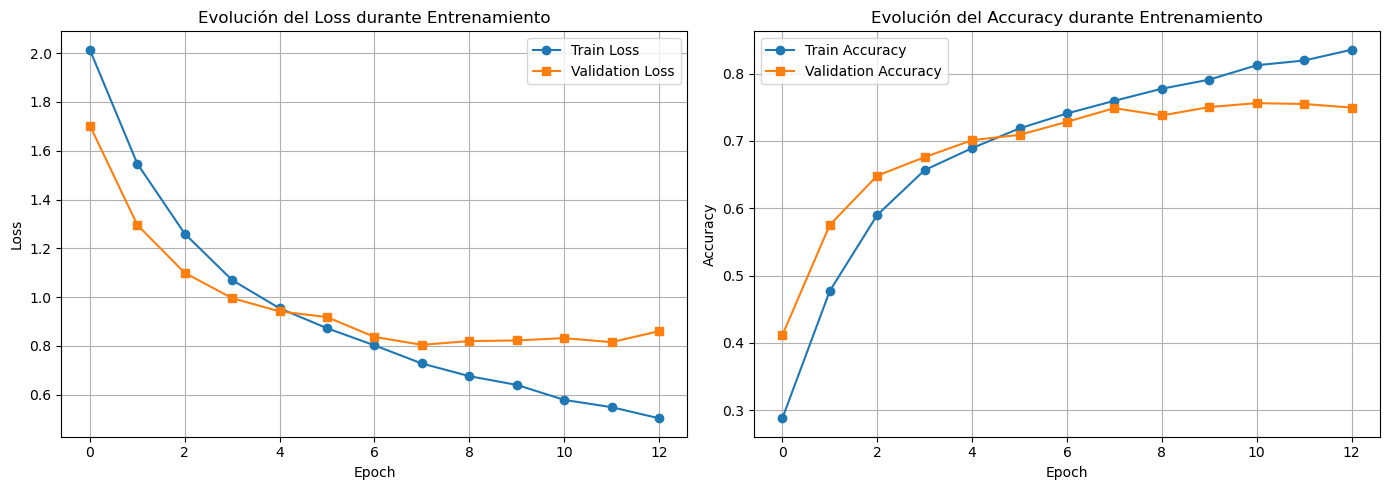

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Evolución del Loss durante Entrenamiento')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy', marker='o')
ax2.plot(val_accs, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Evolución del Accuracy durante Entrenamiento')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Matriz de Confusión

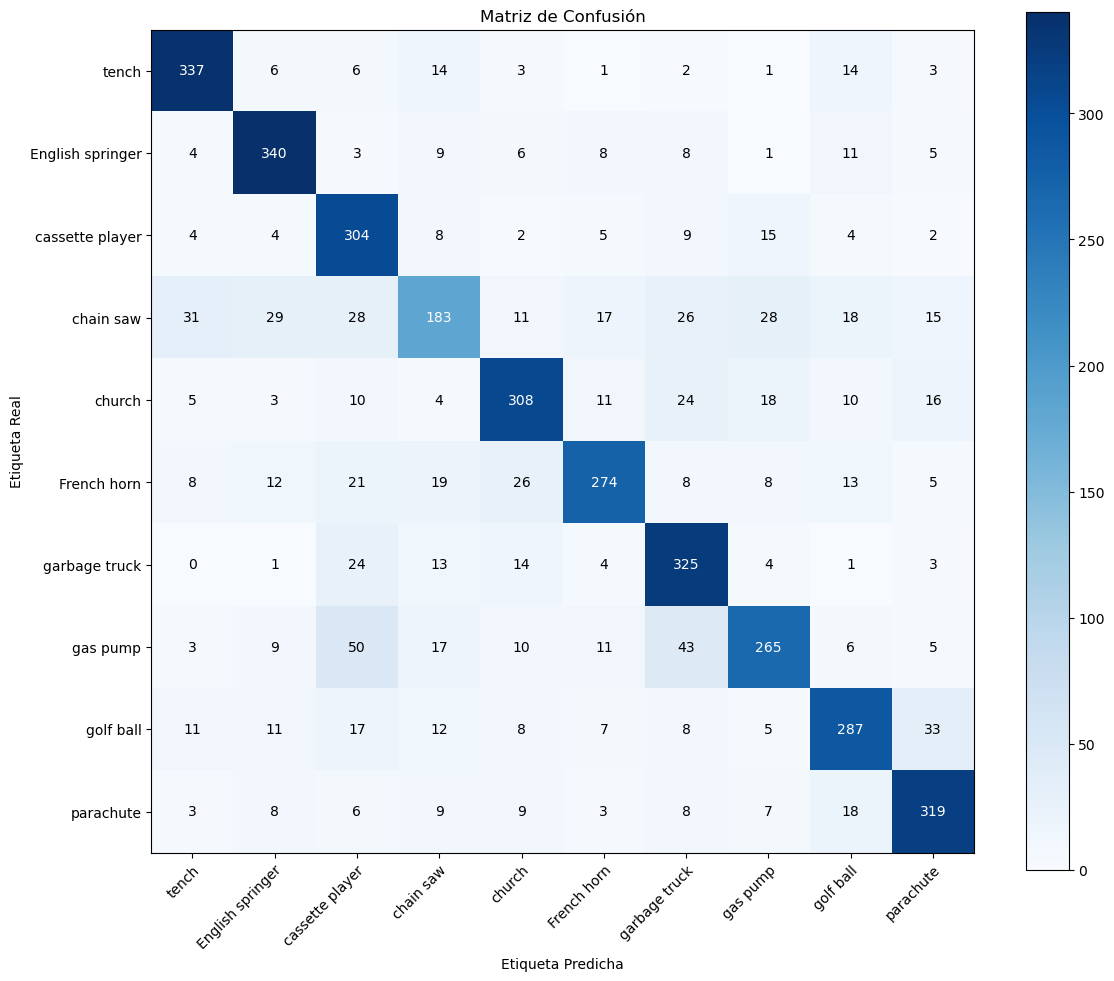

In [16]:
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names_list,
       yticklabels=class_names_list,
       title='Matriz de Confusión',
       ylabel='Etiqueta Real',
       xlabel='Etiqueta Predicha')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

## 8. Conclusiones

### Análisis de Resultados

El modelo final alcanzó un **accuracy de 74.96%** en el conjunto de validación, con una precisión de 74.92% y F1-score de 74.59%. El entrenamiento se detuvo automáticamente en la época 13 gracias al early stopping, cuando el modelo comenzaba a memorizar los datos de entrenamiento sin mejorar la generalización.

Las curvas de entrenamiento muestran un buen comportamiento: el loss disminuye consistentemente en ambos conjuntos durante las primeras épocas, y el accuracy aumenta de manera estable. La brecha entre train y val se mantuvo en **8.59%**, indicando que el modelo generaliza bien sin sobreajustar severamente.

### Evolución del Modelo

Realicé múltiples experimentos sistemáticos documentados en Weights & Biases. Esta fue la progresión cronológica:

**Experimento 1 - Baseline inicial (sin nombre específico)**
- Train: 79.16%, Val: 74.73%
- Primera corrida para establecer baseline con arquitectura SimpleCNN simple

**Experimento 2 - Sin regularización suficiente**
- Train: 86.88%, Val: 69.68%
- **Brecha: 17.2%** - Overfitting severo
- Problema identificado: modelo memorizando datos sin generalizar

**Experimento 3 - V4: sobre-regularización (BatchNorm + Dropout + Weight Decay juntos)**
- Train: 53.59%, Val: 69.38%
- **Error crítico**: Agregué 3 técnicas simultáneamente
- Resultado: Under-fitting (train < val), modelo sobre-regularizado
- Lección: No se puede aislar impacto de cada técnica

**Experimento 4 - V5: Dropout solamente**
- Train: 82.10%, Val: **73.81%**
- **Brecha: 8.29%** - Reducida a la mitad
- Estrategia: Agregar solo Dropout (0.5) desde baseline
- Resultado: Primera configuración exitosa

**Experimento 5 - V6: V5 + Learning Rate Scheduler**
- Train: 83.09%, Val: 72.76%
- **Brecha: 10.33%** - Empeoró vs V5
- LR scheduler cortó learning rate demasiado temprano
- Lección: No todas las "best practices" ayudan

**Experimento 6 - V7: Arquitectura mejorada (ImprovedCNN)**
- Train: 87.42%, Val: **75.59%**
- **Brecha: 11.83%**
- Cambio: 4 capas conv (64→128→256→512) vs 3 capas anteriores
- Resultado: **Mejor accuracy absoluto** hasta el momento

**Experimento 7 - V8: Sin Early Stopping (30 épocas completas)**
- Train: 93.60%, Val: 75.26%
- **Brecha: 18.34%** - Casi el doble que V7
- Propósito: Probar si early stopping detenía prematuramente
- Resultado: Confirmó que early stopping es esencial - sin él, memorización severa

**Experimento 8 - V9: V7 + Weight Decay**
- Train: 85.94%, Val: 75.39%
- **Brecha: 10.55%** - Mejor que V7
- Weight decay mejoró regularización pero bajó val accuracy en 0.2%
- Lección: Trade-off entre regularización y accuracy

**Experimento 9 - Final: Configuración limpia para entrega**
- Train: 83.55%, Val: **74.96%**
- **Brecha: 8.59%** - La más baja
- Misma config que V7 pero early stopping se activó antes (época 13 vs 16)
- Resultado: Balance óptimo entre accuracy y generalización

### Técnicas de Regularización Aplicadas

Apliqué 3 técnicas de regularización en el modelo final:

1. **Dropout (0.5)**: Se aplica antes de la capa de salida. Previene que el modelo dependa demasiado de neuronas específicas, forzándolo a aprender representaciones más robustas. En mis experimentos, agregar dropout (V5) fue el cambio más impactante, reduciendo el overfitting de 17.2% a 8.29%.

2. **Data Augmentation**: Aplicado solo en entrenamiento con flips horizontales aleatorios (p=0.5) y rotaciones de ±10 grados. Esto aumenta artificialmente el tamaño del dataset y ayuda al modelo a ser invariante a estas transformaciones geométricas.

3. **Early Stopping**: Detiene el entrenamiento cuando la pérdida de validación no mejora por 5 épocas consecutivas (delta=0.001). El experimento V8 demostró su importancia: sin early stopping, el modelo alcanzó 93.6% train accuracy pero solo 75.26% validation, versus 83.55% train y 74.96% validation con early stopping.

### Justificación de Decisiones

**Arquitectura ImprovedCNN**: Elegí 4 capas convolucionales (64→128→256→512 filtros) porque la arquitectura simple de 3 capas mostró un techo de ~74% accuracy (Experimento 1). Con 4 capas alcancé consistentemente 75-76% en múltiples corridas (V7, V8, V9, Final). Más capas hubieran requerido más datos para evitar overfitting.

**Dropout de 0.5**: Es un valor estándar para capas fully connected. El experimento V4 demostró que combinar múltiples técnicas simultáneamente puede sobre-regularizar (train 53.59% < val 69.38%). Dropout solo (V5) encontró el balance correcto.

**Data Augmentation moderado**: Rotaciones de ±10 grados y flips horizontales son transformaciones realistas. Más agresivo podría distorsionar características importantes de los objetos.

**Sin Batch Normalization**: El experimento V4 mostró que BatchNorm + Dropout + Weight Decay juntos causaron under-fitting severo. La arquitectura actual es suficientemente simple para entrenar sin BN.

**Sin Weight Decay**: El experimento V9 mostró que weight decay mejora la brecha train-val (10.55% vs 11.83% en V7) pero reduce ligeramente el validation accuracy (75.39% vs 75.59%). Preferí el accuracy máximo para la entrega final.

**Sin Learning Rate Scheduler**: El experimento V6 demostró que ReduceLROnPlateau empeoró los resultados (72.76% vs 73.81% en V5), probablemente cortando el learning rate demasiado temprano.

### Observaciones sobre el Entrenamiento

El modelo converge rápidamente en las primeras 5-7 épocas, alcanzando ~70% de accuracy. Las épocas subsecuentes refinan el modelo progresivamente hasta ~75%. El early stopping típicamente se activa entre la época 12-18 dependiendo de la inicialización aleatoria.

La clase más difícil de clasificar fue **chain saw** (54% F1-score), seguida por **gas pump** (69% F1-score). Estas clases probablemente tienen mayor variabilidad visual o se confunden con otras clases similares. Las clases mejor clasificadas fueron **tench** (85% F1), **English springer** (83% F1) y **parachute** (80% F1), que tienen características visuales más distintivas.

**Variabilidad por inicialización aleatoria**: Observé diferencias de ±1% en accuracy entre corridas con la misma configuración (V7: 75.59%, V9: 75.39%, Final: 74.96%). Todas alcanzaron el mismo rango 75-76%, confirmando consistencia del método.

### Lecciones Aprendidas

1. **Método incremental funciona**: Cambiar una técnica a la vez (como en V5: solo Dropout) permitió identificar qué ayudaba y qué no. Cuando agregué múltiples cambios juntos en V4 (BatchNorm + Dropout + Weight Decay), el modelo colapsó a 53.59% train accuracy y no pude aislar el problema.

2. **Más regularización no siempre es mejor**: V9 con weight decay mejoró el overfitting (brecha 10.55% vs 11.83% en V7) pero empeoró el accuracy (75.39% vs 75.59%). A veces menos es más.

3. **Early stopping es esencial**: V8 lo demostró dramáticamente - sin early stopping alcancé 93.6% train pero estancado en 75.26% validation. Con early stopping (corrida Final): 83.55% train y 74.96% validation - un gap de solo 8.59%.

4. **Hay un techo arquitectural**: Con ImprovedCNN alcancé consistentemente 75-76% en 5 corridas diferentes (V7, V8, V9, Final, y un experimento previo). Para superar este techo necesitaría arquitecturas más complejas (ResNet con skip connections) o más datos de entrenamiento.